# Primary model performance comparison with original bracket layout restored

This notebook preserves the original nested x-axis structure. Each metric group keeps the model-family labels under the bars, the straight square-edged bracket line immediately above the metric text, and the metric text underneath the bracket.

The only added change is that each metric group now has its own four bar labels underneath the metric text, so the previous two-label legend problem is resolved without removing the original bracket line.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
project_root = cwd.parent if cwd.name == "notebooks" else cwd
output_dir = project_root / "op" / "3_participant_split_perf_compare"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Output directory: {output_dir}")

Project root: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0
Output directory: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/3_participant_split_perf_compare


In [2]:
data = [
    {
        "model_family": "Logistic regression",
        "predictor_set": "Clinical-only",
        "legend_label": "Clinical only",
        "auroc": 0.750,
        "average_precision": 0.386,
        "brier_score": 0.203,
        "balanced_accuracy": 0.684,
    },
    {
        "model_family": "Logistic regression",
        "predictor_set": "Clinical + LLM-enhanced medication-state",
        "legend_label": "Clinical + LLM-enhanced medication-state information",
        "auroc": 0.772,
        "average_precision": 0.420,
        "brier_score": 0.196,
        "balanced_accuracy": 0.711,
    },
    {
        "model_family": "Histogram-based gradient boosting",
        "predictor_set": "Clinical-only",
        "legend_label": "Clinical only",
        "auroc": 0.776,
        "average_precision": 0.429,
        "brier_score": 0.190,
        "balanced_accuracy": 0.703,
    },
    {
        "model_family": "Histogram-based gradient boosting",
        "predictor_set": "Clinical + LLM-enhanced medication-state",
        "legend_label": "Clinical + LLM-enhanced medication-state information",
        "auroc": 0.791,
        "average_precision": 0.456,
        "brier_score": 0.184,
        "balanced_accuracy": 0.718,
    },
]

df = pd.DataFrame(data)
table_path = output_dir / "primary_internal_test_performance_table.csv"
df.to_csv(table_path, index=False)
print(f"Saved table to: {table_path}")
df

Saved table to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/3_participant_split_perf_compare/primary_internal_test_performance_table.csv


,model_family,predictor_set,legend_label,auroc,average_precision,brier_score,balanced_accuracy
0,Logistic regression,Clinical-only,Clinical only,0.750,0.386,0.203,0.684
1,Logistic regression,Clinical + LLM-enhanced medication-state,Clinical + LLM-enhanced medication-state infor...,0.772,0.420,0.196,0.711
2,Histogram-based gradient boosting,Clinical-only,Clinical only,0.776,0.429,0.190,0.703
3,Histogram-based gradient boosting,Clinical + LLM-enhanced medication-state,Clinical + LLM-enhanced medication-state infor...,0.791,0.456,0.184,0.718


In [3]:
def plot_nested_metric_groups(
    df,
    metric_pairs,
    output_path,
    title,
    y_label="Performance metric",
    y_lim=None,
    brier_note=False,
):
    """Create grouped bar plots preserving the original bracket above each metric label."""
    from matplotlib.patches import Rectangle

    model_families = ["Logistic regression", "Histogram-based gradient boosting"]
    family_display = {
        "Logistic regression": "Logistic regression",
        "Histogram-based gradient boosting": "Histogram-based\ngradient boosting",
    }
    family_short = {
        "Logistic regression": "Logistic",
        "Histogram-based gradient boosting": "HGB",
    }
    predictor_order = [
        ("Clinical-only", "clinical-only"),
        ("Clinical + LLM-enhanced medication-state", "clinical + LLM medication-state"),
    ]

    group_gap = 1.55
    family_gap = 0.70
    bar_width = 0.24

    fig, ax = plt.subplots(figsize=(8.0, 5.9))

    metric_centers = []
    family_centers = []
    metric_label_items = {metric_label: [] for metric_label, _ in metric_pairs}

    for m_idx, (metric_label, metric_key) in enumerate(metric_pairs):
        metric_origin = m_idx * group_gap
        fam_centers_this_metric = []

        for f_idx, family in enumerate(model_families):
            family_center = metric_origin + (f_idx - 0.5) * family_gap
            fam_centers_this_metric.append(family_center)
            family_centers.append((family_center, family_display[family]))

            for p_idx, (predictor_set, predictor_short_label) in enumerate(predictor_order):
                xpos = family_center + (p_idx - 0.5) * bar_width
                value = float(
                    df.loc[
                        (df["model_family"] == family)
                        & (df["predictor_set"] == predictor_set),
                        metric_key,
                    ].iloc[0]
                )

                bars = ax.bar(xpos, value, width=bar_width)
                color = bars.patches[0].get_facecolor()

                metric_label_items[metric_label].append(
                    (color, f"{family_short[family]}: {predictor_short_label}")
                )

                ax.text(
                    xpos,
                    value + 0.010,
                    f"{value:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                    rotation=0,
                )

        metric_centers.append((np.mean(fam_centers_this_metric), metric_label))

    # Keep the original model-family labels under each metric group.
    ax.set_xticks([x for x, _ in family_centers])
    ax.set_xticklabels([label for _, label in family_centers], fontsize=9)
    ax.tick_params(axis="x", pad=6)

    # Restore the original bracket location: bracket line ABOVE the metric text.
    # The line sits between the model-family labels and the metric label text.
    xaxis_transform = ax.get_xaxis_transform()
    for metric_center, metric_label in metric_centers:
        label_y = -0.245
        bracket_y = -0.185
        bracket_tick_top = -0.155
        left = metric_center - (family_gap / 2) - 0.36
        right = metric_center + (family_gap / 2) + 0.36

        ax.plot(
            [left, right],
            [bracket_y, bracket_y],
            transform=xaxis_transform,
            clip_on=False,
            linewidth=1.0,
            color="black",
        )
        ax.plot(
            [left, left],
            [bracket_y, bracket_tick_top],
            transform=xaxis_transform,
            clip_on=False,
            linewidth=1.0,
            color="black",
        )
        ax.plot(
            [right, right],
            [bracket_y, bracket_tick_top],
            transform=xaxis_transform,
            clip_on=False,
            linewidth=1.0,
            color="black",
        )

        ax.text(
            metric_center,
            label_y,
            metric_label,
            transform=xaxis_transform,
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold",
        )

    # Add metric-specific bar labels below each metric label.
    for metric_center, metric_label in metric_centers:
        label_items = metric_label_items[metric_label]
        x_start = metric_center - 0.62
        text_x = x_start + 0.08
        square_x = x_start
        start_y = -0.335
        row_gap = 0.060

        for row_idx, (color, item_label) in enumerate(label_items):
            y_pos = start_y - row_idx * row_gap
            ax.add_patch(
                Rectangle(
                    (square_x, y_pos - 0.018),
                    0.040,
                    0.030,
                    transform=xaxis_transform,
                    facecolor=color,
                    edgecolor="none",
                    clip_on=False,
                )
            )
            ax.text(
                text_x,
                y_pos,
                item_label,
                transform=xaxis_transform,
                ha="left",
                va="center",
                fontsize=7.8,
            )

    if len(metric_pairs) > 1:
        for m_idx in range(1, len(metric_pairs)):
            separator = (m_idx - 0.5) * group_gap
            ax.axvline(separator, linestyle="--", linewidth=0.8, alpha=0.35)

    ax.set_ylabel(y_label)
    ax.set_title(title, pad=12)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if y_lim is not None:
        ax.set_ylim(*y_lim)

    if brier_note:
        ax.text(
            0.5,
            -0.615,
            "Note: Lower values indicate better performance for Brier score; higher values indicate better performance for average precision.",
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=8.4,
        )

    fig.subplots_adjust(bottom=0.47)
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    fig.savefig(output_path.with_suffix(".pdf"), bbox_inches="tight")
    plt.show()
    print(f"Saved figure to: {output_path}")
    print(f"Saved PDF version to: {output_path.with_suffix('.pdf')}")


## Figure 1. AUROC and balanced accuracy

The bottom x-axis shows AUROC and balanced accuracy as major metric groups. Within each metric group, logistic regression and histogram-based gradient boosting are shown side by side.

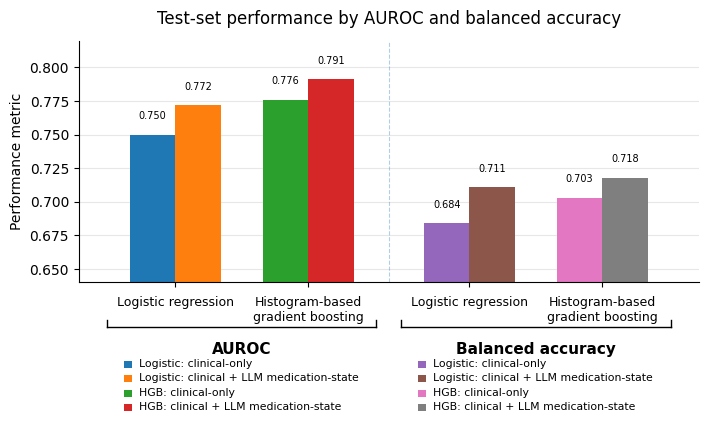

Saved figure to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/3_participant_split_perf_compare/figure_primary_internal_test_auroc_balanced_accuracy_original_layout_fixed.png
Saved PDF version to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/3_participant_split_perf_compare/figure_primary_internal_test_auroc_balanced_accuracy_original_layout_fixed.pdf


In [4]:
plot_nested_metric_groups(
    df=df,
    metric_pairs=[
        ("AUROC", "auroc"),
        ("Balanced accuracy", "balanced_accuracy"),
    ],
    output_path=output_dir / "figure_primary_internal_test_auroc_balanced_accuracy_original_layout_fixed.png",
    title="Test-set performance by AUROC and balanced accuracy",
    y_label="Performance metric",
    y_lim=(0.64, 0.82),
    brier_note=False,
)

## Figure 2. Average precision and Brier score

The bottom x-axis shows average precision and Brier score as major metric groups. Within each metric group, logistic regression and histogram-based gradient boosting are shown side by side.

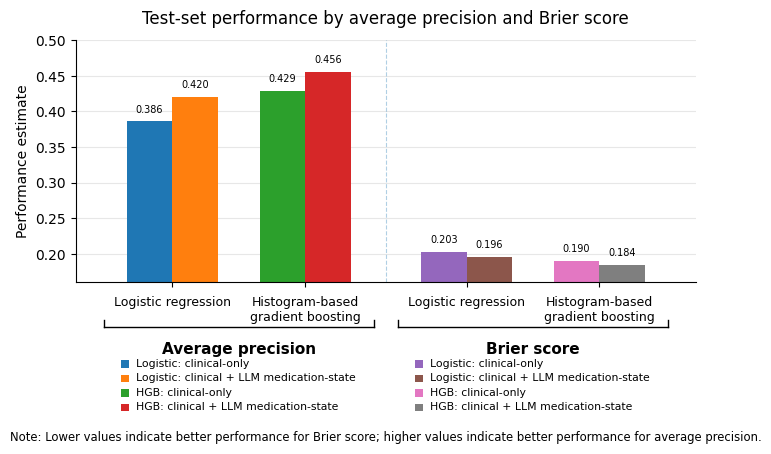

Saved figure to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/3_participant_split_perf_compare/figure_primary_internal_test_ap_brier_original_layout_fixed.png
Saved PDF version to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/3_participant_split_perf_compare/figure_primary_internal_test_ap_brier_original_layout_fixed.pdf


In [5]:
plot_nested_metric_groups(
    df=df,
    metric_pairs=[
        ("Average precision", "average_precision"),
        ("Brier score", "brier_score"),
    ],
    output_path=output_dir / "figure_primary_internal_test_ap_brier_original_layout_fixed.png",
    title="Test-set performance by average precision and Brier score",
    y_label="Performance estimate",
    y_lim=(0.16, 0.50),
    brier_note=True,
)

## Incremental value summary

In [6]:
def make_incremental_summary(df):
    """Create a two-row incremental performance summary.

    Incremental value =
    Clinical + LLM-enhanced medication-state information minus clinical-only.
    """

    model_families = [
        "Logistic regression",
        "Histogram-based gradient boosting",
    ]

    model_display = {
        "Logistic regression": "Logistic regression",
        "Histogram-based gradient boosting": "Histogram gradient boosting",
    }

    clinical_label = "Clinical-only"
    llm_label = "Clinical + LLM-enhanced medication-state"

    metric_pairs = [
        ("AUROC", "auroc"),
        ("Average precision", "average_precision"),
        ("Brier score", "brier_score"),
        ("Balanced accuracy", "balanced_accuracy"),
    ]

    rows = []

    for family in model_families:
        clinical_row = df.loc[
            (df["model_family"] == family)
            & (df["predictor_set"] == clinical_label)
        ].iloc[0]

        llm_row = df.loc[
            (df["model_family"] == family)
            & (df["predictor_set"] == llm_label)
        ].iloc[0]

        row = {
            "Model family": model_display[family],
            "Model comparison": (
                f"{model_display[family]}: Clinical only vs. "
                f"Clinical + LLM-enhanced medication-state information"
            ),
        }

        for metric_label, metric_key in metric_pairs:
            row[f"Δ {metric_label}"] = (
                float(llm_row[metric_key]) - float(clinical_row[metric_key])
            )

        rows.append(row)

    return pd.DataFrame(rows)

In [7]:
def plot_incremental_value_only(
    incremental_summary,
    output_path,
    title="Incremental value of LLM-enhanced medication-state information",
):
    """Plot incremental value summary only."""

    metric_order = [
        "AUROC",
        "Average precision",
        "Brier score",
        "Balanced accuracy",
    ]

    family_order = [
        "Logistic regression",
        "Histogram gradient boosting",
    ]

    plot_df = incremental_summary.melt(
        id_vars=["Model family", "Model comparison"],
        var_name="Metric",
        value_name="Incremental value",
    )

    plot_df["Metric"] = plot_df["Metric"].str.replace("Δ ", "", regex=False)

    x = np.arange(len(metric_order))
    width = 0.36

    fig, ax = plt.subplots(figsize=(7.0, 4.5))

    for idx, family in enumerate(family_order):
        values = []

        for metric in metric_order:
            value = float(
                plot_df.loc[
                    (plot_df["Model family"] == family)
                    & (plot_df["Metric"] == metric),
                    "Incremental value",
                ].iloc[0]
            )
            values.append(value)

        offset = -width / 2 if idx == 0 else width / 2

        bars = ax.bar(
            x + offset,
            values,
            width=width,
            label=family,
        )

        for bar in bars:
            value = bar.get_height()
            va = "bottom" if value >= 0 else "top"
            text_offset = 0.001 if value >= 0 else -0.001

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + text_offset,
                f"{value:+.3f}",
                ha="center",
                va=va,
                fontsize=9,
                rotation=0,
            )

    ax.axhline(0, linewidth=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_order, fontsize=10)
    ax.set_ylabel("Incremental change")
    ax.set_title(title, pad=18)

    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Fixed y-axis range for manuscript readability.
    ax.set_ylim(-0.02, 0.04)

    ax.legend(
        frameon=False,
        ncol=2,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.10),
        fontsize=10,
    )

    fig.text(
        0.5,
        -0.000,
        "Note: Positive values indicate higher AUROC, average precision, and balanced accuracy. "
        "For Brier score, negative values indicate lower probabilistic prediction error.",
        ha="center",
        va="top",
        fontsize=9,
    )

    fig.subplots_adjust(bottom=0.28)

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    fig.savefig(output_path.with_suffix(".pdf"), bbox_inches="tight")

    plt.show()

    print("Saved incremental value figure to:", output_path)
    print("Saved PDF version to:", output_path.with_suffix(".pdf"))

,Model family,Model comparison,Δ AUROC,Δ Average precision,Δ Brier score,Δ Balanced accuracy
0,Logistic regression,Logistic regression: Clinical only vs. Clinica...,0.022,0.034,-0.007,0.027
1,Histogram gradient boosting,Histogram gradient boosting: Clinical only vs....,0.015,0.027,-0.006,0.015


Saved incremental summary to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/3_participant_split_perf_compare/table_primary_internal_test_incremental_value_numeric.csv


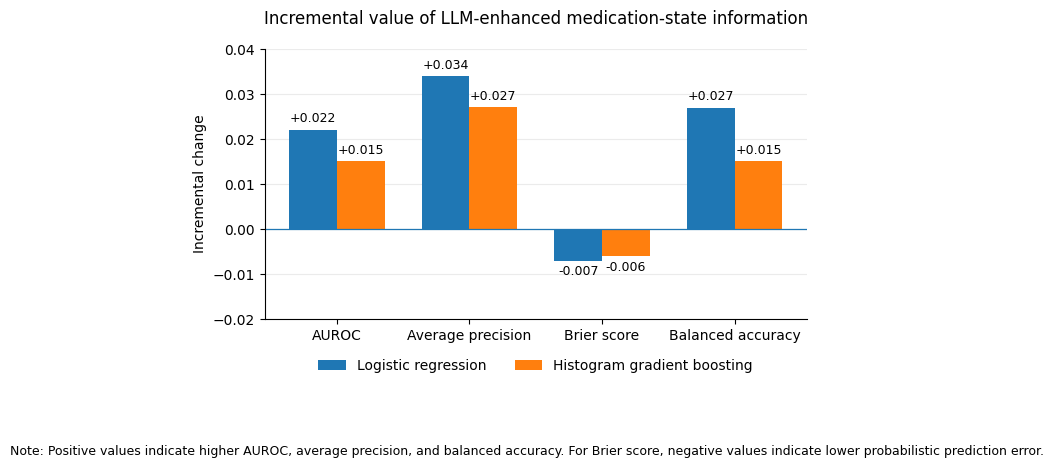

Saved incremental value figure to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/3_participant_split_perf_compare/figure_primary_internal_test_incremental_value.png
Saved PDF version to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/3_participant_split_perf_compare/figure_primary_internal_test_incremental_value.pdf


In [8]:
incremental_summary = make_incremental_summary(df)

display(incremental_summary)

incremental_summary_path = output_dir / "table_primary_internal_test_incremental_value_numeric.csv"
incremental_summary.to_csv(incremental_summary_path, index=False)

print("Saved incremental summary to:", incremental_summary_path)

plot_incremental_value_only(
    incremental_summary=incremental_summary,
    output_path=output_dir / "figure_primary_internal_test_incremental_value.png",
    title="Incremental value of LLM-enhanced medication-state information",
)

## Manuscript-ready captions

**Figure X. Primary internal test-set discrimination and threshold-based performance.** AUROC and balanced accuracy are shown for the four primary model arms. Within each metric group, clinical-only and clinical plus LLM-enhanced medication-state models are compared separately for logistic regression and histogram-based gradient boosting. The nested labels beneath each metric identify the four bars within that metric group.

**Figure Y. Primary internal test-set precision-recall and probabilistic error performance.** Average precision and Brier score are shown for the four primary model arms. Within each metric group, clinical-only and clinical plus LLM-enhanced medication-state models are compared separately for logistic regression and histogram-based gradient boosting. Lower Brier score indicates lower probabilistic prediction error. The nested labels beneath each metric identify the four bars within that metric group.